# Case study: diagnosing a model on clinical-trial data

This is the paper's case study (Section 6.3). It takes a real database —
RelBench's `rel-trial`, 15 tables and 5.8M rows of clinical trial records and a model
trained to predict whether a study achieves its primary outcome, then asks what the model
actually relies on.

The real database is **deliberately polluted** with three synthetic scenarios:

| Scenario | What was planted | Which language should find it |
|---|---|---|
| **Original** | nothing | all three, as a baseline |
| **Column leakage** | a `preliminary_evaluation` table with a `preliminary_evaluation.rating` attribute correlated with the outcome | `Projection` |
| **Tuple leakage** | `preliminary_evaluation.rating` leaks *only* for certain evaluation categories indicated by `preliminary_evaluation.eval_category ∈ {A,B,C}` | `Projection`, then `Selection` |
| **Structural** | the label becomes "has more than one sponsor" | `FKJoin` (and `Projection` should find *nothing*) |

The tuple-leakage scenario is the one that needs all three languages. `Projection` can say
*"the eval_category column matters"* but not *which* categories. Only `Selection`, which
highlights important groups of tuples (satisfying a selection predicate), can say that.

> Reference: Rissaki, Fountalis, Gatterbauer, Kimelfeld.
> *Database Views as Explanations for Relational Deep Learning.* PVLDB 19(7), 2026.

## Setup

This notebook needs the `rel-trial` bundles. **They are large**: the constructed graph is
16.6 GB per database variant, ~50 GB in total, because 98% of it is dense text embeddings
over 5.8M rows. The graphs are shipped.

Scenarios that share a database share one copy of the graph (Original and Structural differ
only in their task labels), so the download is three graphs, not four.

**Runtime.** Each scenario loads a 16.6 GB graph and learns masks for 250 epochs. The interventions themselves can be regenerated with
`python scripts/generate_clinical_trial_interventions.py`.

In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from rdl_explain.artifacts import load_bundle, load_explanation_task
from rdl_explain.explain.explainer import RDLExplainer
from rdl_explain.explain.masks import (discretize_mask, mask_scores,
                                       explanation_size, DEFAULT_DELTA)
from rdl_explain.explain.filters import collect_candidate_filters_given_important_columns
from rdl_explain.explain.viz import plot_mask_importances

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_INSTANCES = 100      # the paper explains 100 instances per task
N_EPOCHS = 250         # the paper's mask-learning budget
EPS = 0.1              # weight on explanation size

# Comment out scenarios to run a subset.
SCENARIOS = {
    "Original":       "rel-trial/study-outcome",
    "Column leakage": "rel-trial/study-outcome-leakage-column",
    "Tuple leakage":  "rel-trial/study-outcome-leakage-tuple",
    "Structural":     "rel-trial/study-outcome-sponsor-count",
}
print("device:", DEVICE)

device: cuda


## The two explanation languages over schema elements

`Projection` (which columns) and `FKJoin` (which joins), exactly as in the previous
notebooks. `Selection` needs its own treatment and comes later, because its candidate
predicates are built *from* the columns `Projection` finds important.

In [2]:
LANGUAGES = {
    "Projection": ("column", "permutation_joint", "permutation_joint"),
    "FKJoin":     ("fkpk",   "zero",              "foreign_key_uniform_random"),
}


def explain(bundle, languages=LANGUAGES, eps=EPS, seed=0):
    # Load a verified bundle and run the given languages on it.
    torch.manual_seed(seed)
    model, data, col_stats, config, manifest = load_bundle(bundle, device=DEVICE)
    task = load_explanation_task(bundle, subsample_per_split=N_INSTANCES)
    explainer = RDLExplainer(config, model, data, task)

    results = {}
    for language, (mask_type, elimination, perturbation) in languages.items():
        mask, _, _ = explainer.learn_masks(
            explanation_type=mask_type, elimination_strategy=elimination,
            eps=eps, n_epochs=N_EPOCHS, lr=0.05,
        )
        hard = discretize_mask(mask)
        dev, sem, *_ = explainer.estimate_devdelta(
            mask=hard, explanation_type=mask_type,
            perturbation_strategy=perturbation, num_samples=5,
        )
        results[language] = {
            "mask": mask, "hard": hard, "dev": dev, "sem": sem,
            "k": explanation_size(hard),
            "kept": sorted({f"{k[0]}.{k[1]}" if language == "Projection"
                            else f"{k[0]}-{k[2]}"
                            for k, v in hard.items() if bool(v.any())}),
        }
    return explainer, data, col_stats, results


def report(name, results, top_k=20):
    for language, r in results.items():
        plot_mask_importances(r["mask"], delta=DEFAULT_DELTA, top_k=top_k,
                              title=f"{name} — {language} "
                                    f"(devDelta = {r['dev']:.4f})")
        plt.show()
        print(f"{language:11s} k={r['k']:3d}/{len(r['hard']):<4d} "
              f"devDelta={r['dev']:.4f}  keeps: {r['kept'] or 'NOTHING'}")

## 1. Original — the baseline

No intervention. This is the model as trained on the real task, and it gives a sense of how
much of a 15-table schema the model actually depends on.

In [ ]:
explainer_o, data_o, stats_o, results_o = explain(SCENARIOS["Original"], eps=0.01)

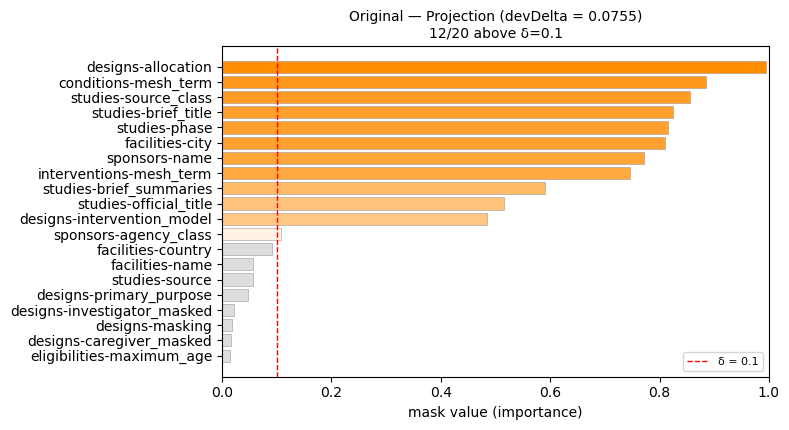

Projection  k= 12/110  devDelta=0.0755  keeps: ['conditions.mesh_term', 'designs.allocation', 'designs.intervention_model', 'facilities.city', 'interventions.mesh_term', 'sponsors.agency_class', 'sponsors.name', 'studies.brief_summaries', 'studies.brief_title', 'studies.official_title', 'studies.phase', 'studies.source_class']


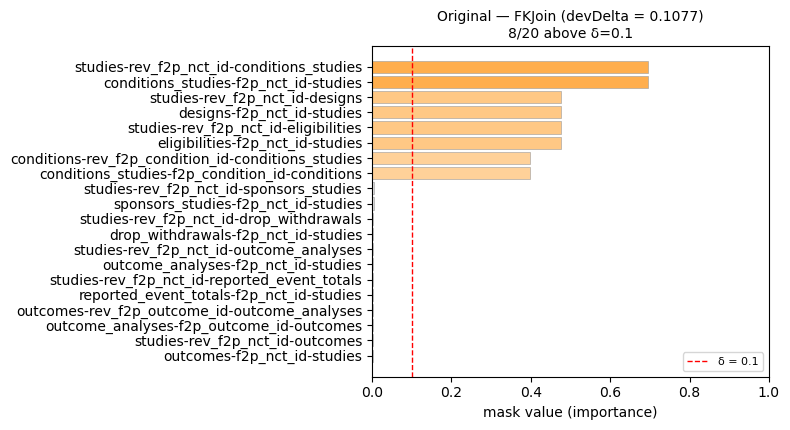

FKJoin      k=  8/30   devDelta=0.1077  keeps: ['conditions-conditions_studies', 'conditions_studies-conditions', 'conditions_studies-studies', 'designs-studies', 'eligibilities-studies', 'studies-conditions_studies', 'studies-designs', 'studies-eligibilities']


In [4]:
report("Original", results_o)

## 2. Column leakage — a column that should not exist

A `preliminary_evaluation` table was added whose `rating` correlates with the outcome. This
is the classic accident: an evaluation recorded *after* the fact leaks the answer. The model
reaches suspiciously high accuracy, and `Projection` should point straight at the culprit.

In [ ]:
explainer_c, data_c, stats_c, results_c = explain(SCENARIOS["Column leakage"])

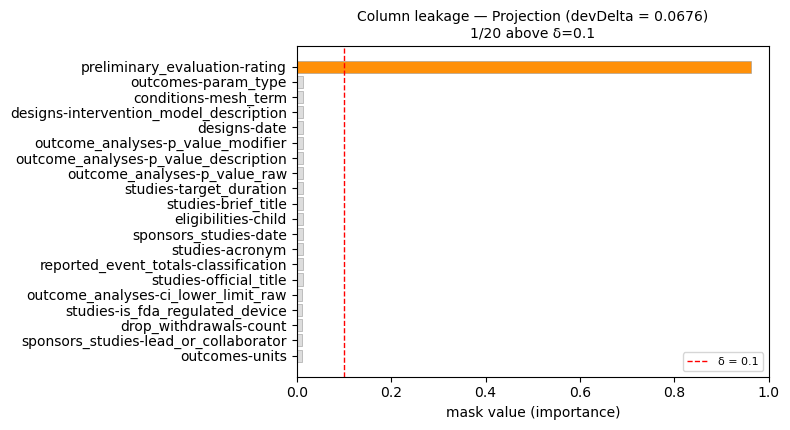

Projection  k=  1/111  devDelta=0.0676  keeps: ['preliminary_evaluation.rating']


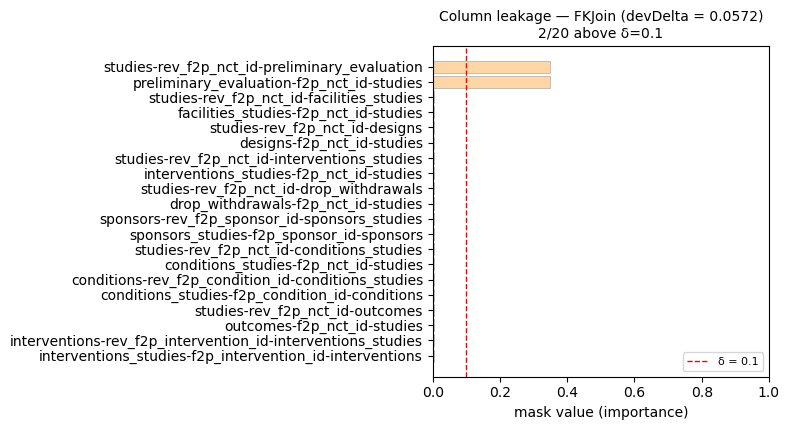

FKJoin      k=  2/32   devDelta=0.0572  keeps: ['preliminary_evaluation-studies', 'studies-preliminary_evaluation']


In [6]:
report("Column leakage", results_c)

`Projection` collapses a 100+ column schema to essentially one column,
`preliminary_evaluation.rating` — the planted leak. That is the diagnosis a practitioner
needs: not "the model is too good", but *which column* to go and look at.

## 3. Tuple leakage — where `Projection` is not enough

Now the leak is subtler. Reviews carry an `eval_category` with ten values, and `rating`
correlates with the outcome **only** for categories A, B and C; for D–J it is noise.

`Projection` will flag `rating` and `eval_category` as important — correctly — but it
cannot express *which* categories are the problem. A column is either in the view or not.

In [ ]:
explainer_t, data_t, stats_t, results_t = explain(SCENARIOS["Tuple leakage"])

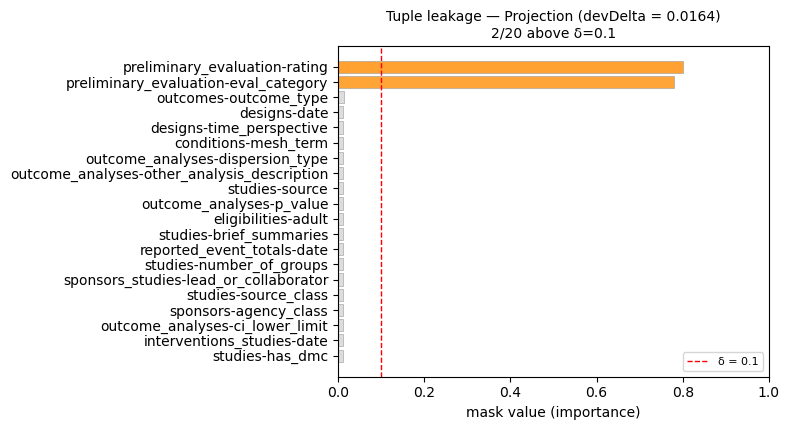

Projection  k=  2/112  devDelta=0.0164  keeps: ['preliminary_evaluation.eval_category', 'preliminary_evaluation.rating']


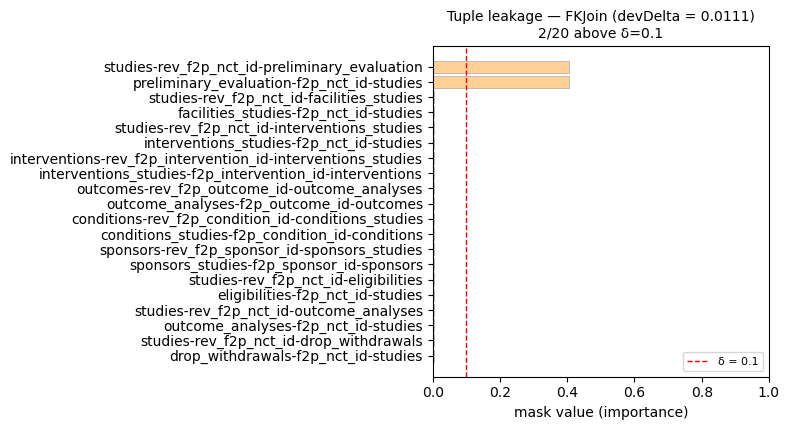

FKJoin      k=  2/32   devDelta=0.0111  keeps: ['preliminary_evaluation-studies', 'studies-preliminary_evaluation']


In [8]:
report("Tuple leakage", results_t)

### `Selection`: filtering tuples rather than columns

`Selection` explanations have the form `select * from R where φ`. Mask learning needs a
finite candidate set of atomic predicates, built from the columns `Projection` just found
important: a categorical column contributes one predicate per category.

One mask value is then learned per predicate, and a tuple is kept or masked as a whole —
paper Section 5.2(3), where multiple predicates on one table combine with the Łukasiewicz
t-conorm `min(1, Σ m_φ)`.

In [9]:
# Candidate predicates over the columns Projection kept.
important = [k for k, v in sorted(mask_scores(results_t["Projection"]["mask"]).items(),
                                  key=lambda kv: -kv[1]) if v >= DEFAULT_DELTA]
candidates, value_mapping = collect_candidate_filters_given_important_columns(
    data_t, stats_t, important)
usable = [c for c in candidates if c[3] != "dummy"]
print(f"{len(usable)} usable candidate predicates from {len(important)} important columns:")
for c in usable:
    print(f"    {c[0]}.{c[1]}  op={c[3]}  {len(c[4])} values")

2 usable candidate predicates from 2 important columns:
    preliminary_evaluation.rating  op=range  4 values
    preliminary_evaluation.eval_category  op=equality  10 values


In [ ]:
# Learn a Selection mask over the eval_category predicate.
predicate = next(c for c in usable if c[1] == "eval_category")
categories = {v: m for nt, col, m in value_mapping if col == "eval_category"
              for v, m in m.items()}

torch.manual_seed(0)
filter_mask, _, _ = explainer_t.learn_masks(
    explanation_type="filter", filter_predicates=[predicate],
    elimination_strategy="permutation_independent",
    eps=EPS, n_epochs=N_EPOCHS, lr=0.05,
)

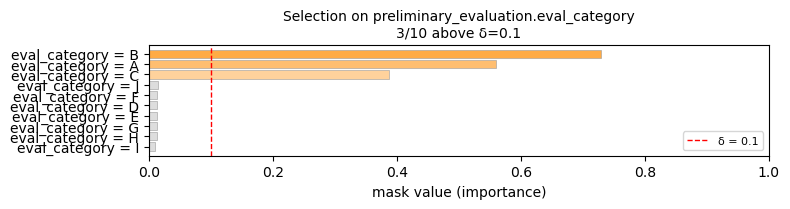

categories in the explanation: ['A', 'B', 'C']
planted ground truth:          ['A', 'B', 'C']


In [11]:
raw = list(filter_mask[0].values())[0].detach().cpu().reshape(-1)
selection_mask = {f"{predicate[1]} = {categories.get(v, v)}": raw[i]
                  for i, v in enumerate(predicate[4])}

plot_mask_importances(selection_mask, delta=DEFAULT_DELTA,
                      title=f"Selection on {predicate[0]}.{predicate[1]}")
plt.show()

leaking = sorted(c.split(" = ")[1] for c, s in selection_mask.items()
                 if torch.sigmoid(s).item() >= DEFAULT_DELTA)
print(f"categories in the explanation: {leaking}")
print(f"planted ground truth:          ['A', 'B', 'C']")

`Selection` isolates exactly the categories the leak was planted in. That is the finding
`Projection` structurally could not produce: the problem is not the `eval_category` column but rather three specific values of it, which turns "drop this column" into "these three review
themes are contaminated."

## 4. Structural — signal with no attributes

Here the label was replaced entirely: a study is positive if it has **more than one
sponsor** (with 10% label noise). Nothing about any attribute's *values* matters, only how
many sponsor rows a study is linked to.

This is the rel-trial counterpart of `count-2` in the toy notebook, and the expected result
is the same shape: `Projection` should come up empty while `FKJoin` carries the finding.

In [ ]:
explainer_s, data_s, stats_s, results_s = explain(SCENARIOS["Structural"])

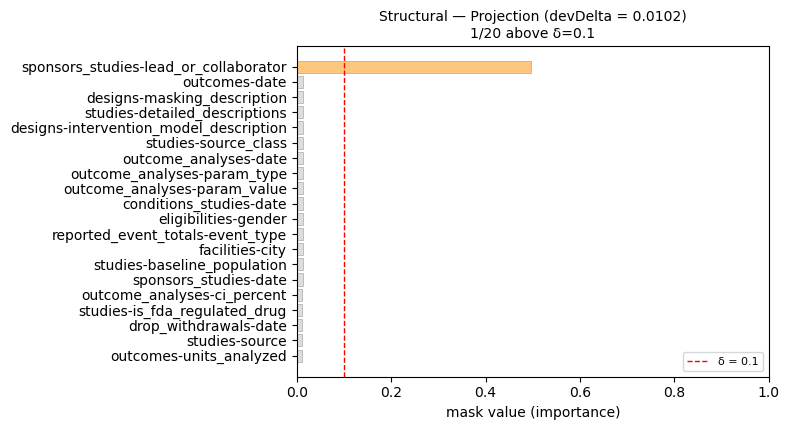

Projection  k=  1/110  devDelta=0.0102  keeps: ['sponsors_studies.lead_or_collaborator']


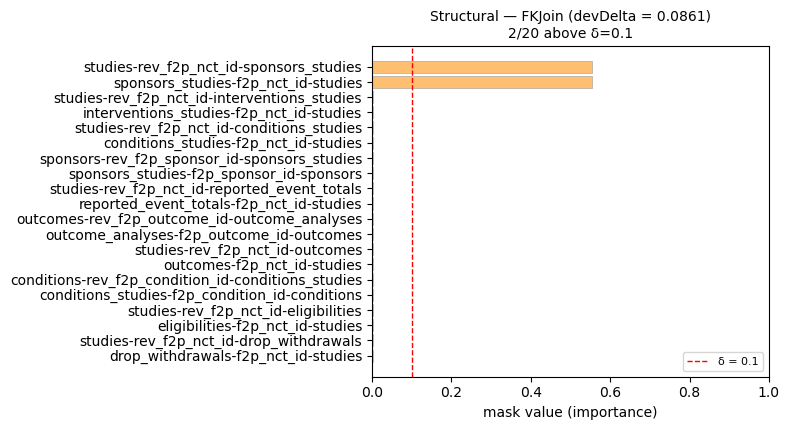

FKJoin      k=  2/30   devDelta=0.0861  keeps: ['sponsors_studies-studies', 'studies-sponsors_studies']


In [13]:
report("Structural", results_s)

## Summary — the paper's Table 1

In [14]:
rows = []
for name, results in (("Original", results_o), ("Column leakage", results_c),
                      ("Tuple leakage", results_t), ("Structural", results_s)):
    for language, r in results.items():
        rows.append({"scenario": name, "language": language, "k": r["k"],
                     "of": len(r["hard"]), "devDelta": round(r["dev"], 4),
                     "kept": ", ".join(r["kept"][:3]) + ("…" if len(r["kept"]) > 3 else "")})
rows.append({"scenario": "Tuple leakage", "language": "Selection",
             "k": len(leaking), "of": len(predicate[4]),
             "devDelta": float("nan"), "kept": ", ".join(leaking)})
pd.set_option("display.max_colwidth", 60)
print(pd.DataFrame(rows).to_string(index=False))

      scenario   language  k  of  devDelta                                                                                      kept
      Original Projection 12 110    0.0755                     conditions.mesh_term, designs.allocation, designs.intervention_model…
      Original     FKJoin  8  30    0.1077 conditions-conditions_studies, conditions_studies-conditions, conditions_studies-studies…
Column leakage Projection  1 111    0.0676                                                             preliminary_evaluation.rating
Column leakage     FKJoin  2  32    0.0572                            preliminary_evaluation-studies, studies-preliminary_evaluation
 Tuple leakage Projection  2 112    0.0164                       preliminary_evaluation.eval_category, preliminary_evaluation.rating
 Tuple leakage     FKJoin  2  32    0.0111                            preliminary_evaluation-studies, studies-preliminary_evaluation
    Structural Projection  1 110    0.0102                           

### What the case study shows

Each problematic scenario is solved by the language able to express it, and **not** by the others:

- a leaking **column** is a `Projection` finding;
- a leak confined to particular **rows** needs `Selection`;
- signal carried by **structure** rather than values shows up only in `FKJoin`, with
  `Projection` correctly returning little or nothing.

That is the argument for a framework spanning several explanation languages rather than a
single notion of column importance. 

The explanations are database views throughout: a projection over columns, a selection
predicate, a join. They are readable by someone who knows the schema and nothing about
GNNs, which is the point of the framework.